El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales donde se emplean filtros de 3x3 y 5x5 en cada capa y se concatenan las salida para la entrada a la capa siguiente

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

Funciones

In [2]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [3]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [4]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = 'E:/bandas/banda13/ene_01_mes'
d_reducida = 'E:/bandas/banda13/ene_01_mes_reducida'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas
# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 741 imágenes
Forma de X: (740, 480, 480, 1)
Forma de y: (740, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:

# Semilla
semilla = 42
tf.random.set_seed(semilla)

# Entrada
inputs = Input(shape=X.shape[1:])

# === Bloque 1 ===
x1_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(inputs)
x1_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(inputs)

res1 = Concatenate()([x1_3, x1_5])

# === Bloque 2 ===
x2_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res1)
x2_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res1)

# 🔗 Conexión residual (concatenación)
res2 = Concatenate()([x2_3, x2_5])
res2 = res2 + res1
res2 = Activation('relu')(res2)

# === Bloque 3 ===
x3_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res2)
x3_5 = Conv2D(16, (5, 5), padding='same', activation= 'relu')(res2)

# 🔗 Conexión residual (concatenación)
res3 = Concatenate()([x3_3, x3_5])
res3 = res3 + res2
res3 = Activation('relu')(res3)

# === Bloque 4 (reducción de canales) ===
x4_3 = Conv2D(16, (3, 3), padding='same', activation='relu')(res3)
x4_5 = Conv2D(16, (5, 5), padding='same', activation='relu')(res3)

# 🔗 Conexión final (concatenación con la salida inicial)
res_final = Concatenate()([x4_3, x4_5])
res_final = res_final + res3
res_final = Activation('relu')(res_final)

# === Salida === Conv 1x1
outputs = Conv2D(1, (1, 1), padding='same', activation='linear')(res_final)

# =====================================================
# PARÁMETROS DEL DECAY COSENOIDAL
# =====================================================
initial_lr = 1e-3       # Tasa de aprendizaje inicial
min_lr = 1e-5           # Tasa mínima al final del entrenamiento
epochs_total = 50       # Debe coincidir con el número de épocas del entrenamiento

# =====================================================
# FUNCIÓN COSINE DECAY (schedule)
# =====================================================
def cosine_decay_schedule(epoch, lr):
    """
    Calcula el decaimiento cosenoidal:
    lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + cos(pi * epoch / total_epochs))
    """
    cosine_decay = 0.5 * (1 + np.cos(np.pi * epoch / epochs_total))
    new_lr = min_lr + (initial_lr - min_lr) * cosine_decay
    return new_lr

# Crear callback de tasa de aprendizaje
lr_scheduler = LearningRateScheduler(cosine_decay_schedule, verbose=1)


# =====================================================
# DEFINICIÓN DEL MODELO
# =====================================================
model12 = Model(inputs=inputs, outputs=outputs)

optimizer = Adam(learning_rate=initial_lr)
model12.compile(
    optimizer=optimizer,
    loss='mse',
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

print("Resumen del modelo:")
model12.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo_12_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
history12 = model12.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint, lr_scheduler],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history12.history['loss'][-1]:.4f}")

Resumen del modelo:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 480, 480,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 480, 480,  │        160 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 480, 480,  │        416 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 480, 480,  │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 32)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 480, 480,  │      4,624 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 480, 480,  │     12,816 │ concatenate[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 480, 480,  │          0 │ conv2d_2[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 480, 480,  │          0 │ concatenate_1[0]… │
│                     │ 32)               │            │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 480, 480,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 480, 480,  │          0 │ conv2d_4[0][0],   │
│ (Concatenate)       │ 32)               │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 480, 480,  │          0 │ concatenate_2[0]… │
│                     │ 32)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 480, 480,  │          0 │ add_1[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 480, 480,  │      4,624 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 480, 480,  │     12,816 │ activation_1[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 480, 480,  │          0 │ conv2d_6[0][0], 

 Total params: 52,929 (206.75 KB)

 Trainable params: 52,929 (206.75 KB)

...

148/148 ━━━━━━━━━━━━━━━━━━━━ 70s 474ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.1217 - root_mean_squared_error: 0.0594 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.1393 - val_root_mean_squared_error: 0.0549 - learning_rate: 8.7058e-05

Epoch 43: LearningRateScheduler setting learning rate to 7.122819337828752e-05.
Epoch 43/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3537 - root_mean_squared_error: 0.0602
Epoch 43: val_loss improved from 0.00301 to 0.00301, saving model to modelo_12_best.h5


148/148 ━━━━━━━━━━━━━━━━━━━━ 70s 473ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.1059 - root_mean_squared_error: 0.0594 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.2166 - val_root_mean_squared_error: 0.0549 - learning_rate: 7.1228e-05

Epoch 44: LearningRateScheduler setting learning rate to 5.711060902932042e-05.
Epoch 44/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3440 - root_mean_squared_error: 0.0602
Epoch 44: val_loss improved from 0.00301 to 0.00301, saving model to modelo_12_best.h5


148/148 ━━━━━━━━━━━━━━━━━━━━ 71s 478ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.0986 - root_mean_squared_error: 0.0594 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.2964 - val_root_mean_squared_error: 0.0549 - learning_rate: 5.7111e-05

Epoch 45: LearningRateScheduler setting learning rate to 4.4760639485315584e-05.
Epoch 45/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3408 - root_mean_squared_error: 0.0601
Epoch 45: val_loss improved from 0.00301 to 0.00300, saving model to modelo_12_best.h5


148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 492ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.1006 - root_mean_squared_error: 0.0594 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.3028 - val_root_mean_squared_error: 0.0548 - learning_rate: 4.4761e-05

Epoch 46: LearningRateScheduler setting learning rate to 3.4227024433899005e-05.
Epoch 46/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3317 - root_mean_squared_error: 0.0601
Epoch 46: val_loss improved from 0.00300 to 0.00300, saving model to modelo_12_best.h5


148/148 ━━━━━━━━━━━━━━━━━━━━ 73s 491ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.1025 - root_mean_squared_error: 0.0594 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.3262 - val_root_mean_squared_error: 0.0548 - learning_rate: 3.4227e-05

Epoch 47: LearningRateScheduler setting learning rate to 2.5551335241327672e-05.
Epoch 47/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.3265 - root_mean_squared_error: 0.0601
Epoch 47: val_loss did not improve from 0.00300
148/148 ━━━━━━━━━━━━━━━━━━━━ 72s 484ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.0955 - root_mean_squared_error: 0.0593 - val_loss: 0.0030 - val_mean_absolute_percentage_error: 12.4741 - val_root_mean_squared_error: 0.0549 - learning_rate: 2.5551e-05

Epoch 48: LearningRateScheduler setting learning rate to 1.8767810889299086e-05.
Epoch 48/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - loss: 0.0036 - mean_absolute_percentage_error: 10.334

Valores de las metricas

RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0035, RMSE final: 0.0593, MAPE final: 10.0682
Validación    - Loss final: 0.0030, RMSE final: 0.0548, MAPE final: 12.3744


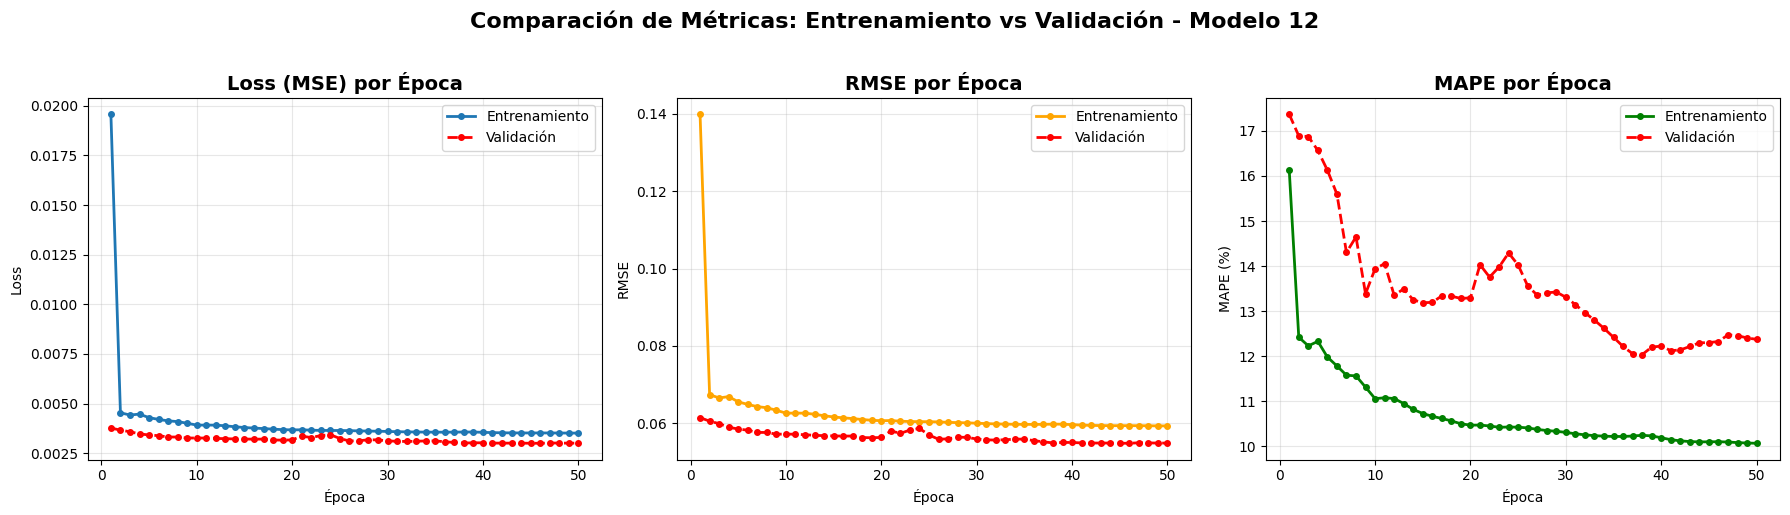

In [6]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history12.history['loss']
val_loss = history12.history['val_loss']

rmse = history12.history['root_mean_squared_error']
val_rmse = history12.history['val_root_mean_squared_error']

mape = history12.history['mean_absolute_percentage_error']
val_mape = history12.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 12',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model12.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 918ms/step - loss: 0.0035 - mean_absolute_percentage_error: 10.0318 - root_mean_squared_error: 0.0593
Pérdida (MSE): 0.0035
RMSE: 0.0593
MAPE: 10.0318


In [8]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model12.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 874ms/step - loss: 0.0030 - mean_absolute_percentage_error: 12.3262 - root_mean_squared_error: 0.0548
Pérdida (MSE): 0.0030
RMSE: 0.0548
MAPE: 12.3262


Visualización de imagenes

19/19 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step


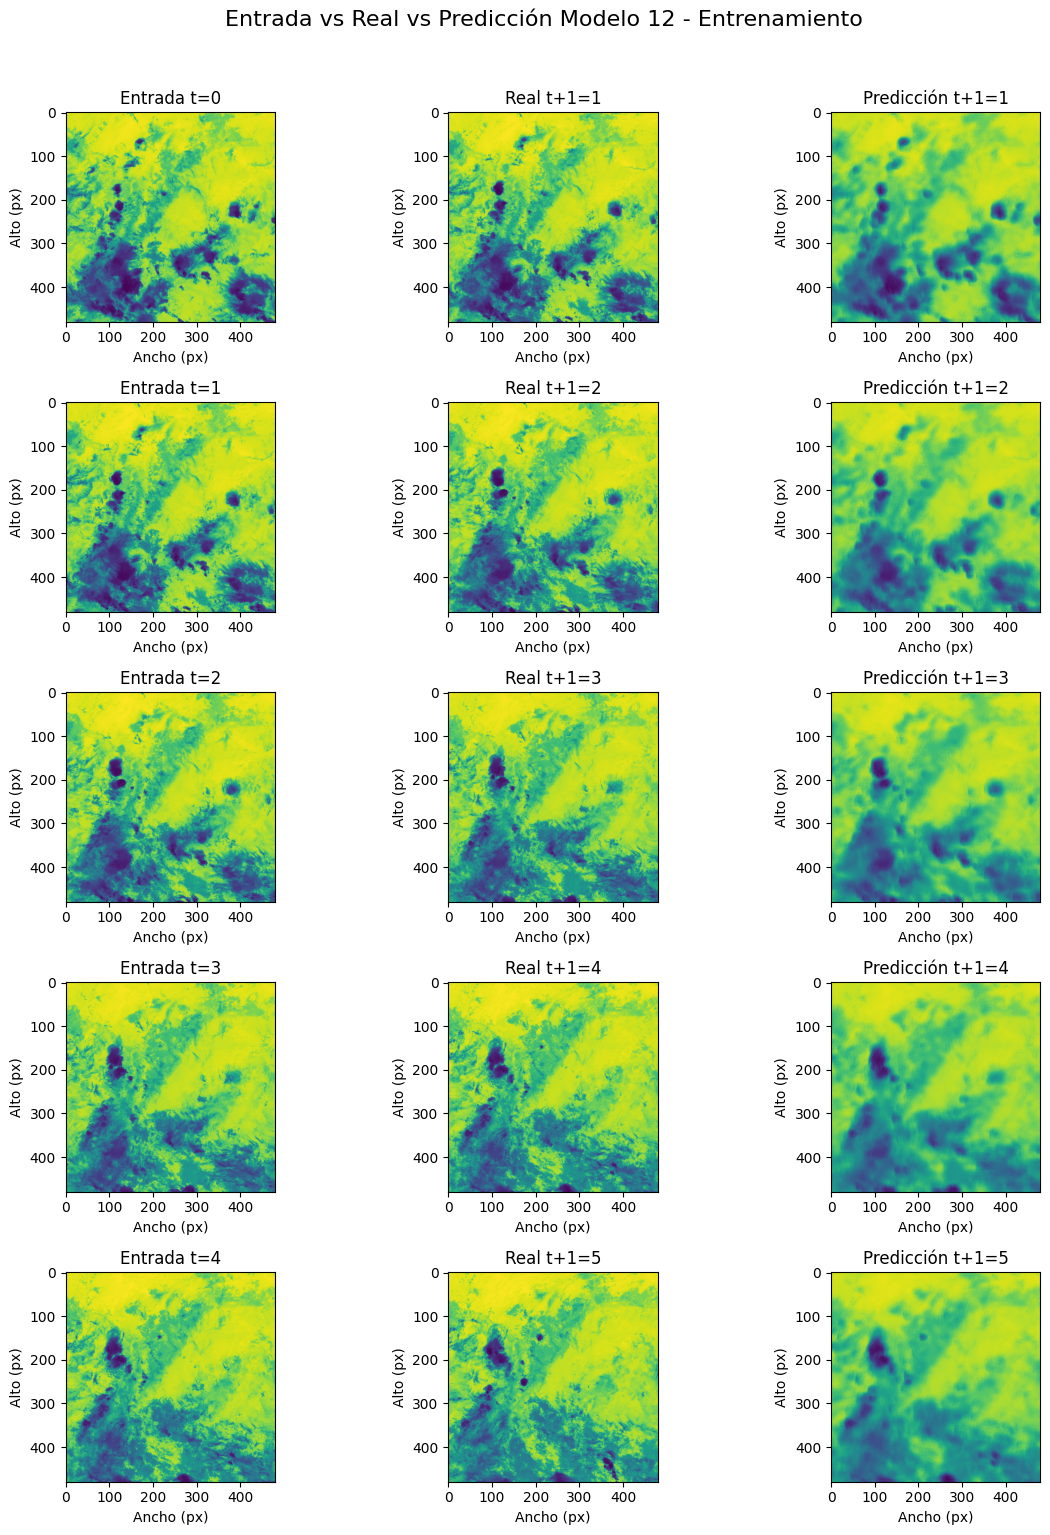

In [9]:
y_pred12 = model12.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_pred12, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba:

In [11]:
# Directorio original y reducido
d_feb_1s = 'E:/bandas/banda13/feb_01_07_1s'
d_feb_1s_red = 'E:/bandas/banda13/feb_01_07_1s_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_feb_1s, d_feb_1s_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_feb_1s_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_test = [np.load(os.path.join(d_feb_1s_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]

X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida

Procesando 167 imágenes
Forma de X: (166, 480, 480, 1)
Forma de y: (166, 480, 480, 1)


Metricas de testeo

In [12]:
# Obtener las métricas del modelo en el conjunto de test
loss, rmse, mape = model12.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 797ms/step - loss: 0.0093 - mean_absolute_percentage_error: 26.1336 - root_mean_squared_error: 0.0965
Pérdida (MSE): 0.0093
RMSE: 0.0965
MAPE: 26.1336


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0035, RMSE final: 0.0593, MAPE final: 10.0682
Validación    - Loss final: 0.0030, RMSE final: 0.0548, MAPE final: 12.3744


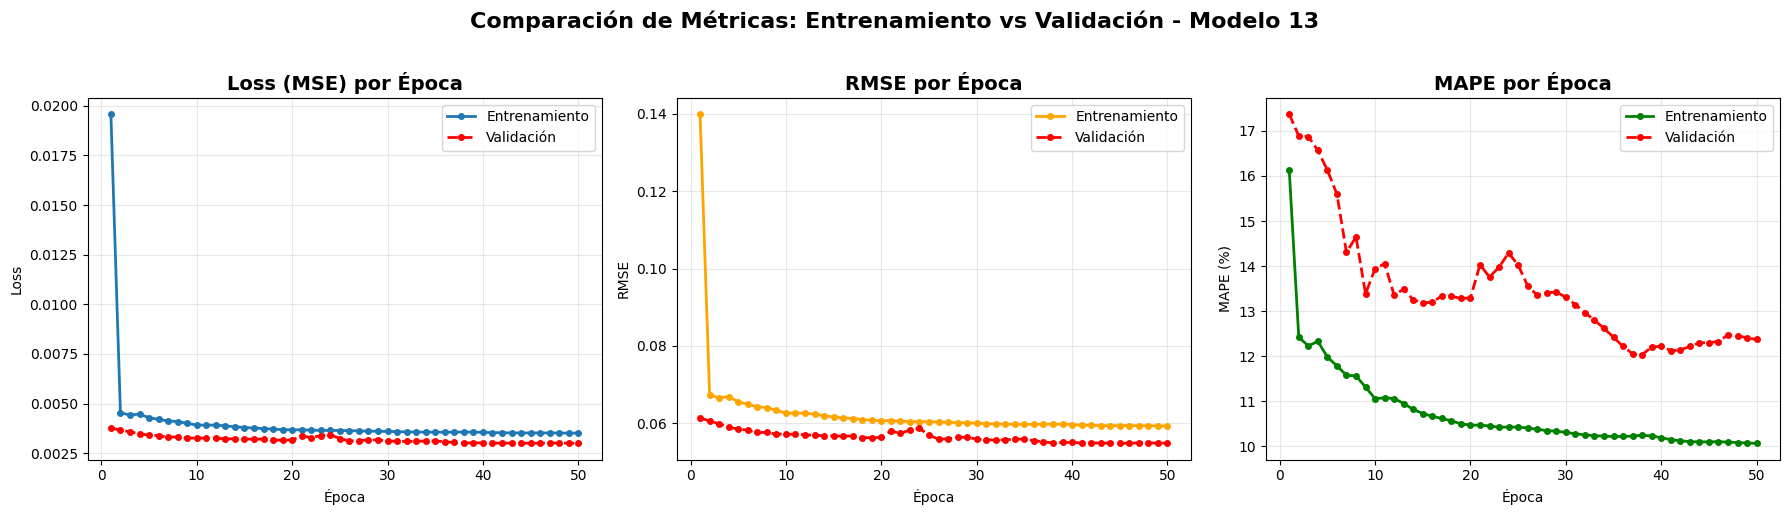

In [14]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history12.history['loss']
val_loss = history12.history['val_loss']

rmse = history12.history['root_mean_squared_error']
val_rmse = history12.history['val_root_mean_squared_error']

mape = history12.history['mean_absolute_percentage_error']
val_mape = history12.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 13',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Visualización de imagenes con conjunto de validación

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 784ms/step


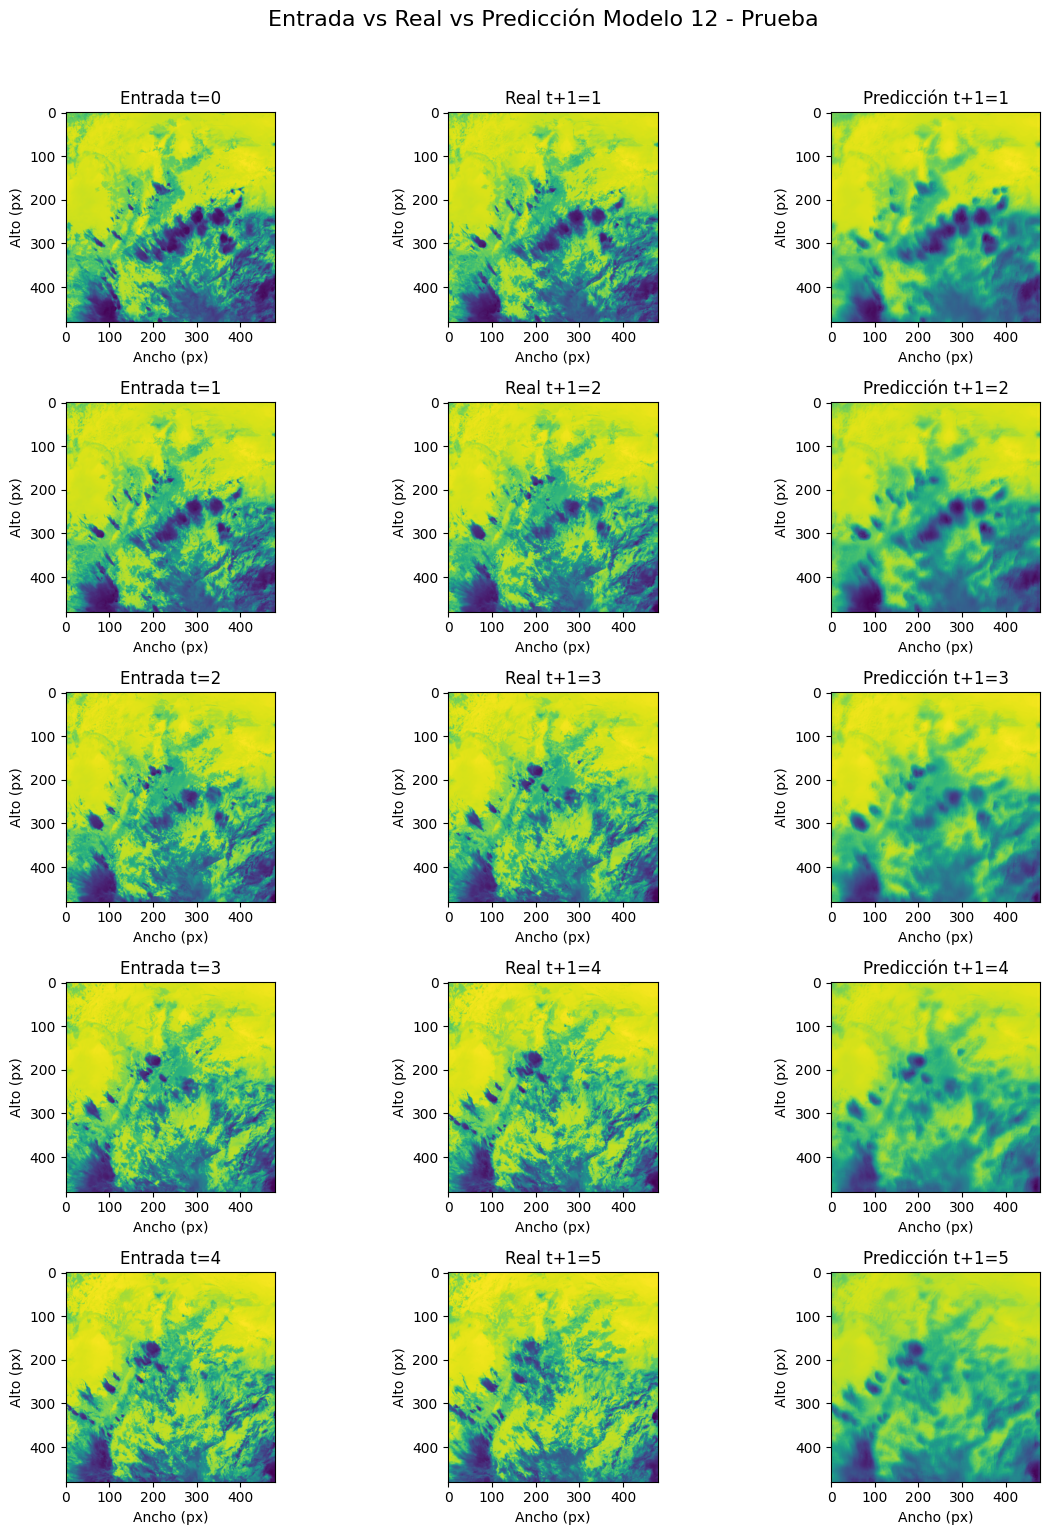

In [13]:
y_pred12_test = model12.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred12_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 12 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)